# RNN - Recurrent Neural Network (PyTorch)

An RNN processes a sequence one token at a time, carrying a **hidden state** forward
so later tokens are interpreted in the context of earlier ones — useful for text,
where word order matters.

We classify real newsgroup posts into one of two topics, **hockey vs. space**, using
`sklearn.datasets.fetch_20newsgroups`: a simple word-level tokenizer + vocabulary,
an embedding layer, and a plain `nn.RNN`.

In [1]:
import re
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.datasets import fetch_20newsgroups

torch.manual_seed(0)

categories = ["rec.sport.hockey", "sci.space"]
train = fetch_20newsgroups(subset="train", categories=categories,
                            remove=("headers", "footers", "quotes"))
test = fetch_20newsgroups(subset="test", categories=categories,
                           remove=("headers", "footers", "quotes"))
len(train.data), len(test.data), train.target_names

(1193, 793, ['rec.sport.hockey', 'sci.space'])

In [2]:
MAX_VOCAB = 5000
MAX_LEN = 150


def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())


train_tokens = [tokenize(doc) for doc in train.data]
test_tokens = [tokenize(doc) for doc in test.data]

counter = Counter(tok for toks in train_tokens for tok in toks)
vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in counter.most_common(MAX_VOCAB - len(vocab)):
    vocab[word] = len(vocab)


def encode(tokens):
    ids = [vocab.get(t, vocab["<unk>"]) for t in tokens][:MAX_LEN]
    ids += [vocab["<pad>"]] * (MAX_LEN - len(ids))
    return ids


X_train = torch.tensor([encode(t) for t in train_tokens], dtype=torch.long)
X_test = torch.tensor([encode(t) for t in test_tokens], dtype=torch.long)
# real (non-padding) length of every sequence, clamped to at least 1
lengths_train = torch.tensor([max(1, min(len(t), MAX_LEN)) for t in train_tokens], dtype=torch.long)
lengths_test = torch.tensor([max(1, min(len(t), MAX_LEN)) for t in test_tokens], dtype=torch.long)
y_train = torch.tensor(train.target, dtype=torch.float32).view(-1, 1)
y_test = torch.tensor(test.target, dtype=torch.float32).view(-1, 1)

vocab_size = len(vocab)
X_train.shape, vocab_size

(torch.Size([1193, 150]), 5000)

In [3]:
class RNNClassifier(nn.Module):
    def __init__(self, vocab_size, emb_dim=32, hidden_dim=32):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=0)
        self.rnn = nn.RNN(emb_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        embedded = self.embedding(x)  # (batch, seq_len, emb_dim)
        # Most posts are far shorter than MAX_LEN; pack_padded_sequence tells the RNN
        # each sequence's real length so it stops recurring there instead of running
        # on through dozens of padding steps and diluting the final hidden state.
        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.rnn(packed)       # hidden: (1, batch, hidden_dim) at the real last step
        return self.fc(hidden.squeeze(0))  # (batch, 1) logits


model = RNNClassifier(vocab_size)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [4]:
losses = []
for epoch in range(30):
    optimizer.zero_grad()
    logits = model(X_train, lengths_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())
    print(f"epoch {epoch+1:2d}  loss {loss.item():.4f}")

epoch  1  loss 0.7000
epoch  2  loss 0.6803
epoch  3  loss 0.6660
epoch  4  loss 0.6513


epoch  5  loss 0.6350
epoch  6  loss 0.6159
epoch  7  loss 0.5927
epoch  8  loss 0.5658


epoch  9  loss 0.5345
epoch 10  loss 0.4996
epoch 11  loss 0.4658
epoch 12  loss 0.4272


epoch 13  loss 0.3974
epoch 14  loss 0.3572
epoch 15  loss 0.3221
epoch 16  loss 0.2833


epoch 17  loss 0.2576
epoch 18  loss 0.2208
epoch 19  loss 0.2001
epoch 20  loss 0.1709


epoch 21  loss 0.1526
epoch 22  loss 0.1321
epoch 23  loss 0.1246
epoch 24  loss 0.1115


epoch 25  loss 0.1053
epoch 26  loss 0.0935
epoch 27  loss 0.0775
epoch 28  loss 0.0679


epoch 29  loss 0.0640
epoch 30  loss 0.0523


Test accuracy: 0.748


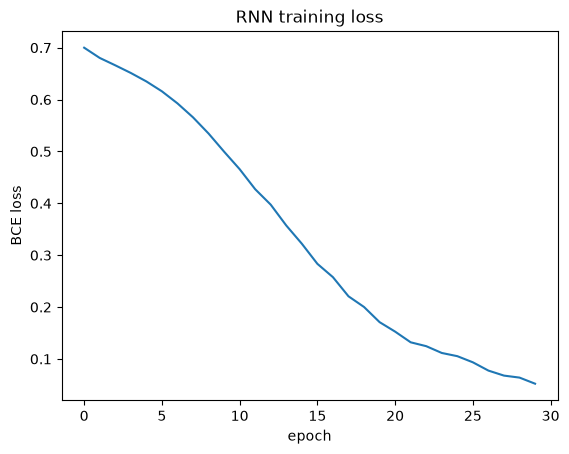

In [5]:
with torch.no_grad():
    preds = torch.sigmoid(model(X_test, lengths_test)) >= 0.5
    accuracy = (preds.float() == y_test).float().mean().item()
print(f"Test accuracy: {accuracy:.3f}")

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("BCE loss")
plt.title("RNN training loss")
plt.show()